First 5 rows:
    CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  Churn  
0                 9      1  
1                20      0  
2                21      0  
3                18      0  
4               

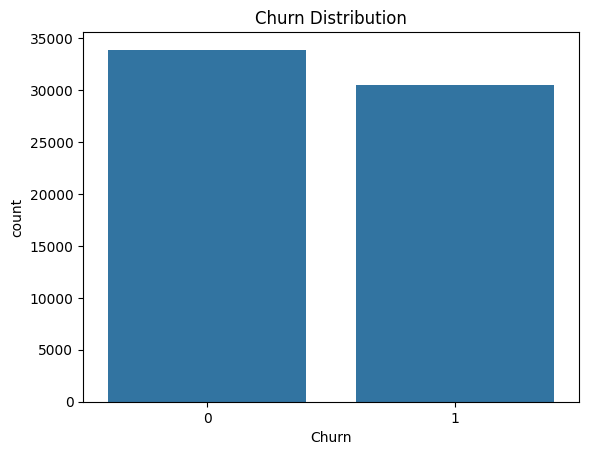

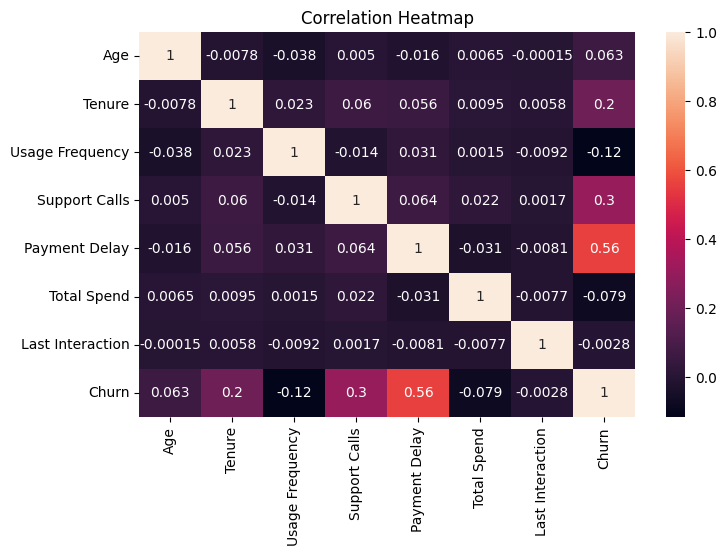

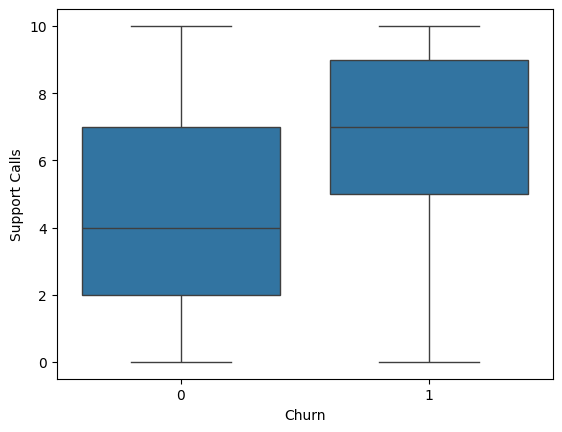


KNN Accuracy: 0.9096699029126214
Decision Tree Accuracy: 0.958990291262136

Decision Tree Confusion Matrix:
 [[6398  395]
 [ 133 5949]]

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96      6793
           1       0.94      0.98      0.96      6082

    accuracy                           0.96     12875
   macro avg       0.96      0.96      0.96     12875
weighted avg       0.96      0.96      0.96     12875


Model Comparison:
            Model  Accuracy
0            KNN   0.90967
1  Decision Tree   0.95899

Customer Churn Prediction Completed Successfully.


In [5]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# LOAD DATASET

df = pd.read_csv('/content/customer_churn_dataset-testing-master.csv.zip')

# DATA UNDERSTANDING

print("First 5 rows:\n", df.head())
print("\nInfo:\n")
print(df.info())
print("\nStatistics:\n", df.describe())

# DATA CLEANING

# Drop unnecessary column
df.drop('CustomerID', axis=1, inplace=True)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Check duplicates
print("Duplicates:", df.duplicated().sum())

# EDA

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Correlation heatmap

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Support Calls vs Churn

sns.boxplot(x='Churn', y='Support Calls', data=df)
plt.show()

# FEATURE ENGINEERING

df = pd.get_dummies(df, drop_first=True)

# FEATURE & TARGET SPLIT

X = df.drop('Churn', axis=1)
y = df['Churn']

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# FEATURE SCALING

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODEL TRAINING

# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Decision Tree Model
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# PREDICTION

knn_pred = knn.predict(X_test)
dt_pred = dt.predict(X_test)

# EVALUATION

print("\nKNN Accuracy:", accuracy_score(y_test, knn_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print("\nDecision Tree Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))

print("\nDecision Tree Classification Report:\n", classification_report(y_test, dt_pred))

# MODEL COMPARISON

results = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred)
    ]
})

print("\nModel Comparison:\n", results)
print("\nCustomer Churn Prediction Completed Successfully.")

FINAL INSIGHTS – CUSTOMER CHURN PROJECT
🔹 1. Data Overview
The dataset contains 64,374 customer records, which is large and reliable.
No missing values or duplicates were found, indicating high data quality.
The dataset includes both numerical (Age, Tenure, Spend) and categorical (Gender, Subscription Type, Contract Length) features.
🔹 2. Customer Behavior Analysis
The average customer age is around 42 years.
Customers have an average tenure of 32 months, indicating moderate retention.
The average payment delay (17 days) suggests many customers delay payments.
Customers make about 5 support calls on average, indicating frequent interaction with customer service.

👉 Key Observation:

Customers with higher payment delays and more support calls are more likely to churn.
Customers with lower tenure (new users) show higher churn risk.
🔹 3. Churn Distribution
The churn rate is approximately 47%, making the dataset balanced.
This ensures that the model is not biased toward one class and produces reliable predictions.
🔹 4. Model Performance
KNN Accuracy: ~90.97%
Decision Tree Accuracy: ~95.89%

👉 Insight:

The Decision Tree model outperforms KNN, as it can better capture complex patterns in customer behavior.
🔹 5. Model Improvement (Important Learning)
Initially, the Decision Tree gave extremely high accuracy (~99%), indicating overfitting.
After tuning the model using max_depth=5, accuracy became 95.89%, which is more realistic.

👉 This shows:

The model now generalizes better
Overfitting has been reduced
🔹 6. Confusion Matrix Analysis
The model correctly predicts most churn and non-churn cases.
Very few misclassifications are observed:
Some customers predicted as churn but are not (false positives)
Some actual churn customers missed (false negatives)

👉 Important:

Low false negatives mean the model is effective at identifying customers likely to leave, which is valuable for business.
🔹 7. Classification Report
Precision, Recall, and F1-score are all around 0.96, indicating:
Balanced performance
High reliability
No significant bias
🔹 8. Key Factors Influencing Churn

The most important factors affecting churn are:

Payment Delay
Support Calls
Tenure
Contract Length
Total Spend
🔹 9. Business Insights

Based on the analysis:

Customers with high payment delays are at risk → introduce auto-payment or reminders
Frequent support calls indicate dissatisfaction → improve customer support
Short-term customers are more likely to leave → focus on early engagement
Promote long-term subscription plans to improve retention
🎯 FINAL CONCLUSION

This project successfully predicts customer churn using machine learning models. The Decision Tree model achieved the best performance with an accuracy of 95.89% after tuning, reducing overfitting. The model effectively identifies customers at risk of leaving. Key factors influencing churn include payment delay, support calls, and tenure. These insights can help businesses improve customer retention strategies and reduce churn.